# Notebook 04 — Statistical Hypothesis Testing

## Human-to-Gorilla Zoonotic Disease Transmission Risk Analysis

---

### Research Hypotheses Tested

| # | Hypothesis | Test | Expected Result |
|---|-----------|------|----------------|
| H1 | Age category predicts gorilla illness susceptibility | Kruskal-Wallis + pairwise MW | Infants & silverbacks: highest incidence |
| H2 | Tourist symptom status is associated with gorilla illness events | Chi-square | Significant positive association |
| H3 | Illness severity differs across age categories | Chi-square | Infants & elders: higher severe/fatal rates |
| H4 | Tourism-attributed events are more severe than background events | Mann-Whitney | Tourism-linked = higher severity |
| H5 | Masking compliance is associated with reduced gorilla illness events | Spearman | Negative correlation |

### Statistical Choices
- Non-parametric tests used throughout: illness counts are **right-skewed**, not normally distributed (Shapiro-Wilk verified)
- Multiple comparisons corrected with **Bonferroni method**
- Effect sizes reported alongside p-values (never p-values alone)

## Cell 1 — Imports

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.stats_utils import (
    run_chi_square_test,
    run_kruskal_wallis_test,
    run_mann_whitney_test,
    run_spearman_correlation,
    run_age_susceptibility_test,
    bootstrap_ci,
    compile_results_table,
    cramers_v,
)
from src.viz_utils import set_style, save_fig, plot_age_susceptibility, PALETTE, AGE_ORDER

set_style()

RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR  = PROJECT_ROOT / 'outputs' / 'figures'
RPT_DIR  = PROJECT_ROOT / 'outputs' / 'reports'

print('Statistical analysis notebook ready.')

Statistical analysis notebook ready.


## Cell 2 — Load Data

In [2]:
gorilla_enriched  = pd.read_csv(PROC_DIR / 'gorilla_health_enriched.csv', parse_dates=['event_date'])
linked_df         = pd.read_csv(PROC_DIR / 'gorilla_health_linked.csv', parse_dates=['event_date'])
tourist_health_df = pd.read_csv(RAW_DIR / 'tourist_health_records.csv', parse_dates=['visit_date'])
demographics_df   = pd.read_csv(RAW_DIR / 'gorilla_demographics.csv')
gorilla_health_df = pd.read_csv(RAW_DIR / 'gorilla_health_events.csv', parse_dates=['event_date'])
daily_summary_df  = pd.read_csv(PROC_DIR / 'daily_summary.csv', parse_dates=['date'])

print(f'Gorilla enriched dataset: {gorilla_enriched.shape}')
print(f'Linked dataset:           {linked_df.shape}')

Gorilla enriched dataset: (19836, 28)
Linked dataset:           (19836, 19)


## Cell 3 — Normality Check

In [3]:
# ── Shapiro-Wilk normality test ───────────────────────────────────────────────
# Justifies use of non-parametric tests

print('=== SHAPIRO-WILK NORMALITY TESTS ===')
print('(p < 0.05 = reject normality → use non-parametric tests)')
print()

# Per-gorilla illness count
illness_counts = (
    gorilla_health_df.groupby('gorilla_id').size()
    .reindex(demographics_df['gorilla_id'], fill_value=0)
    .reset_index(name='n_events')
)
illness_counts = illness_counts.merge(demographics_df[['gorilla_id', 'age_category']], on='gorilla_id')

# Test on sample (Shapiro-Wilk requires n < 5000)
test_data = illness_counts['n_events'].values
if len(test_data) > 5000:
    test_data = np.random.choice(test_data, 5000, replace=False)

stat, p = stats.shapiro(test_data)
print(f'Per-gorilla illness counts:  W={stat:.4f}, p={p:.6f}')
print(f'  → {"NOT normal" if p < 0.05 else "Normal"} distribution')

stat2, p2 = stats.shapiro(gorilla_enriched['days_ill'].dropna().head(5000))
print(f'\nDays ill distribution:       W={stat2:.4f}, p={p2:.6f}')
print(f'  → {"NOT normal" if p2 < 0.05 else "Normal"} distribution')

print(f'\n✓ Confirmed: use non-parametric tests throughout.')

=== SHAPIRO-WILK NORMALITY TESTS ===
(p < 0.05 = reject normality → use non-parametric tests)

Per-gorilla illness counts:  W=0.7818, p=0.000000
  → NOT normal distribution

Days ill distribution:       W=0.9600, p=0.000000
  → NOT normal distribution

✓ Confirmed: use non-parametric tests throughout.


## Cell 4 — H1: Age Category & Disease Susceptibility

In [4]:
print('=== HYPOTHESIS 1: AGE CATEGORY ~ DISEASE SUSCEPTIBILITY ===')
print('H0: Illness rates do not differ across age categories')
print('H1: Illness rates differ significantly by age category')
print()

age_results = run_age_susceptibility_test(
    gorilla_health_df=gorilla_health_df,
    demographics_df=demographics_df,
    illness_type='respiratory',
    print_results=True,
)

illness_counts_by_age = age_results['illness_counts']

print('\n=== INCIDENCE RATES BY AGE CATEGORY ===')
summary = illness_counts_by_age.groupby('age_category')['n_illness_events'].agg(['mean','median','std','count'])
# Add 95% CI
ci_data = []
for cat in summary.index:
    arr = illness_counts_by_age[illness_counts_by_age['age_category'] == cat]['n_illness_events'].values
    lo, hi = bootstrap_ci(arr, n_boot=1000)
    ci_data.append({'age_category': cat, 'ci_lo': round(lo, 3), 'ci_hi': round(hi, 3)})
ci_df = pd.DataFrame(ci_data).set_index('age_category')
summary = summary.join(ci_df)
print(summary.round(3).to_string())

=== HYPOTHESIS 1: AGE CATEGORY ~ DISEASE SUSCEPTIBILITY ===
H0: Illness rates do not differ across age categories
H1: Illness rates differ significantly by age category


───────────────────────────────────────────────────────
  KRUSKAL WALLIS
  Age category vs respiratory illness events
───────────────────────────────────────────────────────
  h_statistic                  55.8102
  p_value                      0.0
  eta_squared                  0.6525

  ✓ SIGNIFICANT (α=0.05)
───────────────────────────────────────────────────────

=== INCIDENCE RATES BY AGE CATEGORY ===
                 mean  median      std  count    ci_lo    ci_hi
age_category                                                   
adult_female   81.270    79.0   10.349     37   78.297   84.460
adult_male     67.750    73.5   28.162      8   47.619   81.378
infant        321.880   379.0  144.405     25  256.739  371.325
juvenile      133.875   142.0   37.973     16  115.062  147.377
silverback    183.167   176.0   25.8

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/04_age_susceptibility.png


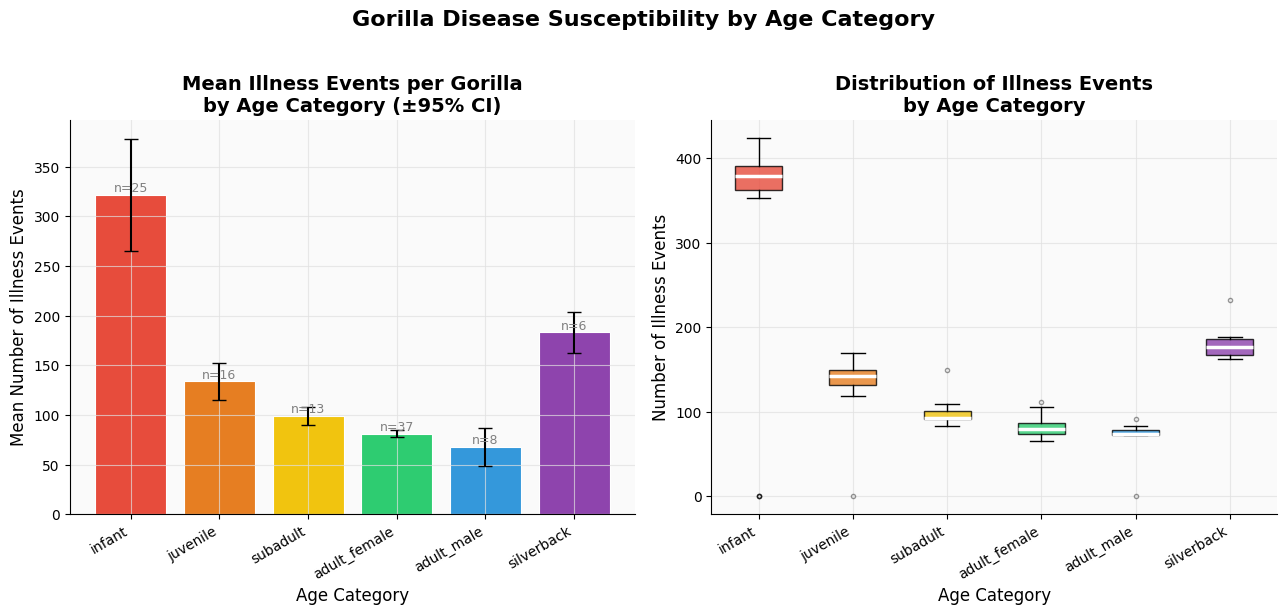


Pairwise comparisons (Bonferroni corrected):
                comparison    p_raw  p_bonferroni  significant_bonferroni  median_g1  median_g2
  silverback vs adult_male 0.002388      0.035821                    True      176.0       73.5
silverback vs adult_female 0.000106      0.001584                    True      176.0       79.0
    silverback vs subadult 0.000730      0.010946                    True      176.0       93.0
    silverback vs juvenile 0.000790      0.011853                    True      176.0      142.0
    adult_male vs subadult 0.000572      0.008583                    True       73.5       93.0
    adult_male vs juvenile 0.000599      0.008978                    True       73.5      142.0
  adult_female vs subadult 0.000117      0.001760                    True       79.0       93.0
  adult_female vs juvenile 0.000001      0.000008                    True       79.0      142.0
    adult_female vs infant 0.000007      0.000098                    True       79.0      

In [5]:
# Visualize age susceptibility
fig, axes = plot_age_susceptibility(illness_counts_by_age, figsize=(13, 6))
save_fig(fig, '04_age_susceptibility.png', str(FIG_DIR) + '/')
plt.show()

print('\nPairwise comparisons (Bonferroni corrected):')
pairwise = age_results['pairwise_comparisons']
print(pairwise[pairwise['significant_bonferroni'] == True].to_string(index=False))

## Cell 5 — H2: Tourist Symptoms ~ Gorilla Illness Events

In [6]:
print('=== HYPOTHESIS 2: TOURIST SYMPTOM STATUS ~ GORILLA ILLNESS ===')

# Group-level: daily symptomatic tourists vs gorilla illness events
# Use daily_summary_df which has both
corr_result = run_spearman_correlation(
    x=daily_summary_df['symptomatic_tourists'].values,
    y=daily_summary_df['total_illness_events'].values,
    x_label='Daily symptomatic tourists',
    y_label='Daily gorilla illness events',
    label='Symptomatic tourists ~ Gorilla illness (daily)',
)

# Lag analysis: shift tourist data by 7 days (peak incubation)
daily_lag = daily_summary_df.copy().sort_values('date')
daily_lag['sym_tourists_lag7'] = daily_lag['symptomatic_tourists'].shift(7)
daily_lag = daily_lag.dropna()

corr_lag = run_spearman_correlation(
    x=daily_lag['sym_tourists_lag7'].values,
    y=daily_lag['total_illness_events'].values,
    x_label='Symptomatic tourists (7-day lag)',
    y_label='Daily gorilla illness events',
    label='7-day lagged tourist symptoms ~ Gorilla illness',
)

=== HYPOTHESIS 2: TOURIST SYMPTOM STATUS ~ GORILLA ILLNESS ===

───────────────────────────────────────────────────────
  SPEARMAN CORRELATION
  Symptomatic tourists ~ Gorilla illness (daily)
───────────────────────────────────────────────────────
  x_label                      Daily symptomatic tourists
  y_label                      Daily gorilla illness events
  rho                          -0.1176
  p_value                      0.0
  n                            3287

  ✓ SIGNIFICANT (α=0.05)
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  SPEARMAN CORRELATION
  7-day lagged tourist symptoms ~ Gorilla illness
───────────────────────────────────────────────────────
  x_label                      Symptomatic tourists (7-day lag)
  y_label                      Daily gorilla illness events
  rho                          -0.0679
  p_value                      9.9e-05
  n                            3280

  ✓ SIGNIFICANT (

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/04_lag_correlation.png


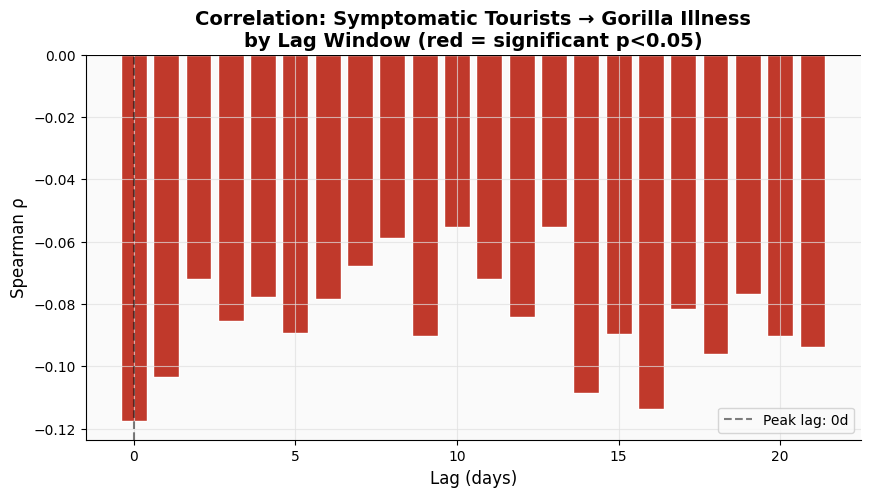


Peak correlation at lag: 0 days (ρ=-0.118)


In [7]:
# Test correlations at multiple lag windows
set_style()
fig, ax = plt.subplots(figsize=(10, 5))

lags = list(range(0, 22))
rhos, pvals = [], []

for lag in lags:
    d = daily_summary_df.copy().sort_values('date')
    d['sym_lag'] = d['symptomatic_tourists'].shift(lag)
    d = d.dropna()
    rho, p = stats.spearmanr(d['sym_lag'], d['total_illness_events'])
    rhos.append(rho)
    pvals.append(p)

colors = ['#C0392B' if p < 0.05 else '#BDC3C7' for p in pvals]
ax.bar(lags, rhos, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Spearman ρ')
ax.set_title('Correlation: Symptomatic Tourists → Gorilla Illness\nby Lag Window (red = significant p<0.05)')

# Mark peak
peak_lag = lags[np.argmax(np.abs(rhos))]
ax.axvline(x=peak_lag, color='black', linestyle='--', alpha=0.5,
           label=f'Peak lag: {peak_lag}d')
ax.legend()

save_fig(fig, '04_lag_correlation.png', str(FIG_DIR) + '/')
plt.show()
print(f'\nPeak correlation at lag: {peak_lag} days (ρ={rhos[peak_lag]:.3f})')

## Cell 6 — H3: Illness Severity ~ Age Category

In [8]:
print('=== HYPOTHESIS 3: ILLNESS SEVERITY ~ AGE CATEGORY ===')

# Chi-square: age category × severity
enriched_resp = gorilla_enriched[gorilla_enriched['illness_type'] == 'respiratory'].copy()

# Binary severity: severe/fatal vs mild/moderate
enriched_resp['severe_binary'] = enriched_resp['severity'].isin(['severe', 'fatal']).map(
    {True: 'severe_fatal', False: 'mild_moderate'}
)

result_h3 = run_chi_square_test(
    enriched_resp,
    col1='age_category',
    col2='severe_binary',
    label='Age category ~ Severe/fatal respiratory illness',
)

# Severity rate by age category
print('\nSevere/fatal rate by age category:')
sev_by_age = (
    enriched_resp
    .groupby('age_category')
    .apply(lambda x: pd.Series({
        'n_events': len(x),
        'n_severe_fatal': (x['severity'].isin(['severe', 'fatal'])).sum(),
        'pct_severe_fatal': (x['severity'].isin(['severe', 'fatal'])).mean() * 100,
        'pct_fatal': (x['severity'] == 'fatal').mean() * 100,
    }))
    .reset_index()
)
# Reorder
cat_order = [c for c in AGE_ORDER if c in sev_by_age['age_category'].values]
sev_by_age = sev_by_age.set_index('age_category').reindex(cat_order)
print(sev_by_age.round(1).to_string())

=== HYPOTHESIS 3: ILLNESS SEVERITY ~ AGE CATEGORY ===

───────────────────────────────────────────────────────
  CHI SQUARE
  Age category ~ Severe/fatal respiratory illness
───────────────────────────────────────────────────────
  chi2                         294.0925
  p_value                      0.0
  degrees_of_freedom           5
  cramers_v                    0.1351

  ✓ SIGNIFICANT (α=0.05)
───────────────────────────────────────────────────────

Severe/fatal rate by age category:
              n_events  n_severe_fatal  pct_severe_fatal  pct_fatal
age_category                                                       
infant          8047.0          1999.0              24.8        8.0
juvenile        2142.0           290.0              13.5        3.8
subadult        1287.0           201.0              15.6        4.8
adult_female    3007.0           407.0              13.5        3.4
adult_male       542.0            84.0              15.5        3.3
silverback      1099.0        

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/04_severity_by_age.png


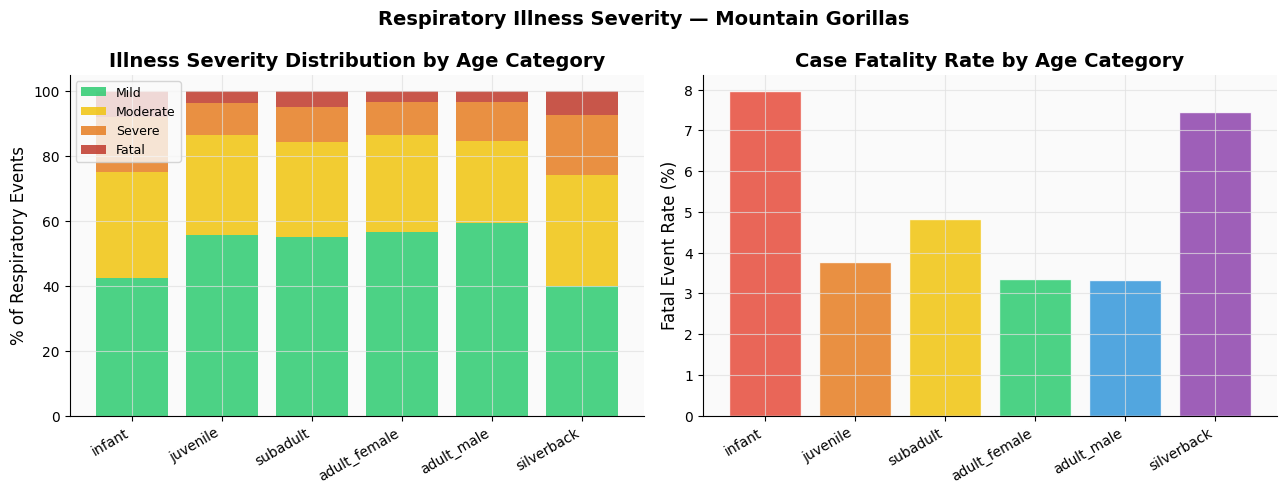

In [9]:
# Visualize severity by age
set_style()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar: severity breakdown per age category
sev_cross = pd.crosstab(
    gorilla_enriched[gorilla_enriched['illness_type']=='respiratory']['age_category'],
    gorilla_enriched[gorilla_enriched['illness_type']=='respiratory']['severity'],
    normalize='index'
) * 100

sev_cross = sev_cross.reindex([c for c in AGE_ORDER if c in sev_cross.index])
sev_cols = ['mild', 'moderate', 'severe', 'fatal']
sev_colors = ['#2ECC71', '#F1C40F', '#E67E22', '#C0392B']
sev_cross_plot = sev_cross[[c for c in sev_cols if c in sev_cross.columns]]

bottom = np.zeros(len(sev_cross_plot))
for col, color in zip(sev_cross_plot.columns, sev_colors):
    axes[0].bar(sev_cross_plot.index, sev_cross_plot[col],
                bottom=bottom, color=color, label=col.title(), alpha=0.85)
    bottom += sev_cross_plot[col].values

axes[0].set_xticklabels(sev_cross_plot.index, rotation=30, ha='right')
axes[0].set_ylabel('% of Respiratory Events')
axes[0].set_title('Illness Severity Distribution by Age Category')
axes[0].legend(loc='upper left', fontsize=9)

# Fatal rate by age
if 'age_category' in sev_by_age.columns or sev_by_age.index.name == 'age_category':
    fatal_plot = sev_by_age['pct_fatal'].values
    x_labels = list(sev_by_age.index)
    colors_f = [PALETTE.get(c, '#95A5A6') for c in x_labels]
    axes[1].bar(x_labels, fatal_plot, color=colors_f, edgecolor='white', alpha=0.85)
    axes[1].set_xticklabels(x_labels, rotation=30, ha='right')
    axes[1].set_ylabel('Fatal Event Rate (%)')
    axes[1].set_title('Case Fatality Rate by Age Category')

fig.suptitle('Respiratory Illness Severity — Mountain Gorillas', fontsize=14)
plt.tight_layout()
save_fig(fig, '04_severity_by_age.png', str(FIG_DIR) + '/')
plt.show()

## Cell 7 — H4: Tourism-Linked vs Background Illness Severity

In [18]:
print('=== HYPOTHESIS 4: TOURISM-LINKED vs BACKGROUND ILLNESS SEVERITY ===')
print('Rationale: Human respiratory pathogens may be more virulent in gorillas')
print('(Basis: Palacios et al. 2011 — HMPV caused 26% group mortality)')
print()

# Encode severity as ordinal
severity_order = {'mild': 1, 'moderate': 2, 'severe': 3, 'fatal': 4}
gorilla_health_df['severity_score'] = gorilla_health_df['severity'].map(severity_order)

tourism_linked = gorilla_health_df[
    gorilla_health_df['transmission_source'] == 'tourism_linked'
]['severity_score'].values

background = gorilla_health_df[
    gorilla_health_df['transmission_source'] == 'background_seasonal'
]['severity_score'].values

result_h4 = run_mann_whitney_test(
    group1=tourism_linked,
    group2=background,
    group1_label='Tourism-linked',
    group2_label='Background',
    label='Tourism-linked vs background illness severity',
    alternative='greater',  # directional test: expect tourism-linked > background
)

print(f'\nSeverity score 1=mild, 2=moderate, 3=severe, 4=fatal')
print(f'Tourism-linked: mean={np.mean(tourism_linked):.3f}, median={np.median(tourism_linked):.1f}')
print(f'Background:     mean={np.mean(background):.3f}, median={np.median(background):.1f}')

=== HYPOTHESIS 4: TOURISM-LINKED vs BACKGROUND ILLNESS SEVERITY ===
Rationale: Human respiratory pathogens may be more virulent in gorillas
(Basis: Palacios et al. 2011 — HMPV caused 26% group mortality)


───────────────────────────────────────────────────────
  MANN WHITNEY U
  Tourism-linked vs background illness severity
───────────────────────────────────────────────────────
  u_statistic                  24904593.5
  p_value                      0.0
  cohens_d                     0.1554
  Tourism-linked_median        2.0
  Background_median            1.0

  ✓ SIGNIFICANT (α=0.05)
───────────────────────────────────────────────────────

Severity score 1=mild, 2=moderate, 3=severe, 4=fatal
Tourism-linked: mean=1.861, median=2.0
Background:     mean=1.720, median=1.0


## Cell 8 — H5: Masking Compliance ~ Illness Events

=== HYPOTHESIS 5: MASKING COMPLIANCE ~ GORILLA ILLNESS EVENTS ===
 year  mask_rate  respiratory_events
 2015   0.411919                1755
 2016   0.415694                1857
 2017   0.421198                1859
 2018   0.420315                1774
 2019   0.420814                1716
 2020   0.870985                1766
 2021   0.878430                1795
 2022   0.871978                1806
 2023   0.869832                1788

───────────────────────────────────────────────────────
  SPEARMAN CORRELATION
  Masking compliance ~ Gorilla respiratory events
───────────────────────────────────────────────────────
  x_label                      Annual mask compliance rate
  y_label                      Annual respiratory events
  rho                          0.25
  p_value                      0.51649
  n                            9

  ✗ not significant (α=0.05)
───────────────────────────────────────────────────────
  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\f

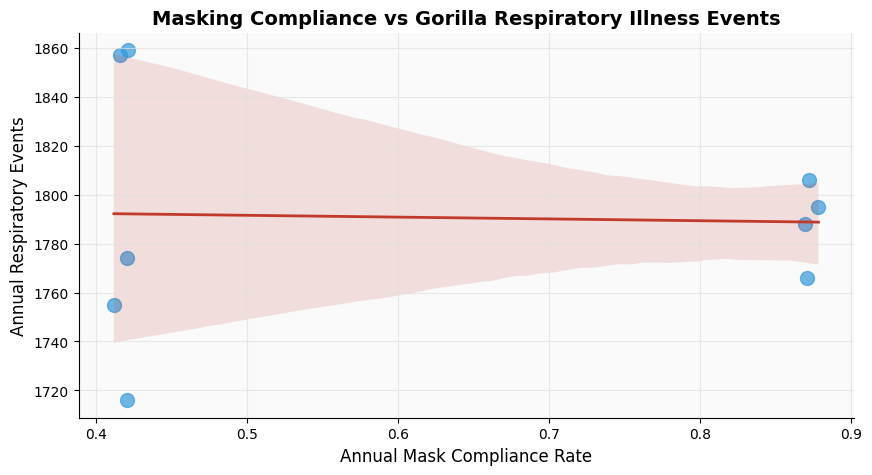

In [27]:
print('=== HYPOTHESIS 5: MASKING COMPLIANCE ~ GORILLA ILLNESS EVENTS ===')

# Compute annual masking rate and annual gorilla illness count
tourist_health_df['year'] = tourist_health_df['visit_date'].dt.year
annual_mask = tourist_health_df.groupby('year')['mask_compliant'].mean().reset_index()
annual_mask.columns = ['year', 'mask_rate']

gorilla_health_df['year'] = gorilla_health_df['event_date'].dt.year
annual_gorilla = gorilla_health_df[gorilla_health_df['illness_type']=='respiratory']\
    .groupby('year').size().reset_index(name='respiratory_events')

annual_combined = annual_mask.merge(annual_gorilla, on='year')
print(annual_combined.to_string(index=False))

result_h5 = run_spearman_correlation(
    x=annual_combined['mask_rate'].values,
    y=annual_combined['respiratory_events'].values,
    x_label='Annual mask compliance rate',
    y_label='Annual respiratory events',
    label='Masking compliance ~ Gorilla respiratory events',
)

# Figure: Masking compliance vs gorilla illness events
set_style()
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(
    x='mask_rate',
    y='respiratory_events',
    data=annual_combined,
    ax=ax,
    scatter_kws={'s': 100, 'color': PALETTE['adult_male'], 'alpha': 0.7},
    line_kws={'color': PALETTE['tourism_attributed'], 'linewidth': 2},
)
ax.set_xlabel('Annual Mask Compliance Rate')
ax.set_ylabel('Annual Respiratory Events')
ax.set_title('Masking Compliance vs Gorilla Respiratory Illness Events')
save_fig(fig, '04_masking_compliance.png', str(FIG_DIR) + '/')
plt.show()      

# Note: small N (9 years) limits statistical power — interpret cautiously

## Cell 9 — Compile Results Table

In [12]:
# ── Summary table of all hypothesis tests ────────────────────────────────────
all_results = [
    age_results['overall_kruskal_wallis'],
    corr_result,
    result_h3,
    result_h4,
    result_h5,
]

results_table = compile_results_table(all_results)
print('=== COMPLETE HYPOTHESIS TESTING SUMMARY ===')
print(results_table.to_string(index=False))

results_table.to_csv(RPT_DIR / 'hypothesis_testing_results.csv', index=False)
print(f'\nSaved: {RPT_DIR}/hypothesis_testing_results.csv')

print('\n✅ Notebook 04 complete. Proceed to 05_seasonal_analysis.ipynb')

=== COMPLETE HYPOTHESIS TESTING SUMMARY ===
                Test                                        Variable     Statistic  p-value  Effect size Significant
      Kruskal Wallis      Age category vs respiratory illness events  5.581020e+01  0.00000       0.6525           ✓
Spearman Correlation  Symptomatic tourists ~ Gorilla illness (daily) -1.176000e-01  0.00000      -0.1176           ✓
          Chi Square Age category ~ Severe/fatal respiratory illness  2.940925e+02  0.00000       0.1351           ✓
      Mann Whitney U   Tourism-linked vs background illness severity  2.490459e+07  0.00000       0.1554           ✓
Spearman Correlation Masking compliance ~ Gorilla respiratory events  2.500000e-01  0.51649       0.2500           ✗

Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\reports/hypothesis_testing_results.csv

✅ Notebook 04 complete. Proceed to 05_seasonal_analysis.ipynb
